***
***
**Q3A. SONIC SIGNATURES**
***
***

In [3]:
!pip install librosa

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.8 MB 4.6 MB/s eta 0:00:01
   -------------------------- ------------- 1.8/2.8 MB 4.4 MB/s eta 0:00:01
   -------------------------------------- - 2.6/2.8 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 3.9 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 5.6 MB/s eta 0:00:07
   - -------------------------------------- 1.8/38.1 MB 5.3 MB/s eta 0:00:07
   -- ------------------------------------- 2.6/38.1 MB 4.4 MB/s eta 0:00:08
   --- ------------------------------------ 3.7/38.1 MB 4.4 MB/s eta 0:00:08
   ---- ----------------------------------- 4.5/38.1 MB 4.3 MB/s eta 0:00:08
   ----- ---------------------------------- 5.2/38.1 MB 4.4 MB/s eta 0:00:08
   ------ --------------------------------- 6.3/38.1 MB 4.4 MB/s eta 0:00:08
   ------- ----------

In [10]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the MP3 file
# librosa automatically decodes the MP3 into a raw numpy array of amplitudes (y)
# and gives you the sampling rate (sr), which is usually 44100 Hz.
file_path = './song data/A Hard Day_s Night.mp3'
y, sr = librosa.load(file_path, sr=None) 
print(y, sr)

[ 0.0000000e+00  1.1378614e-14  6.2844966e-15 ...  3.3444600e-08
  1.1008901e-06 -5.5081705e-07] 48000


In [11]:
# 2. Compute the Fourier Transform (FFT)
# Audio tracks are long, so we take the FFT of the signal. 
# We take the absolute value to get the magnitude (volume) of each frequency.
audio_fft = np.fft.fft(y)
frequencies = np.fft.fftfreq(len(y), d=1/sr)

In [12]:
# 3. Clean up the data for plotting
# Because audio is real-valued, the FFT is symmetrical. We only care about positive frequencies.
positive_frequencies = frequencies[:len(frequencies)//2]
magnitude = np.abs(audio_fft)[:len(audio_fft)//2]

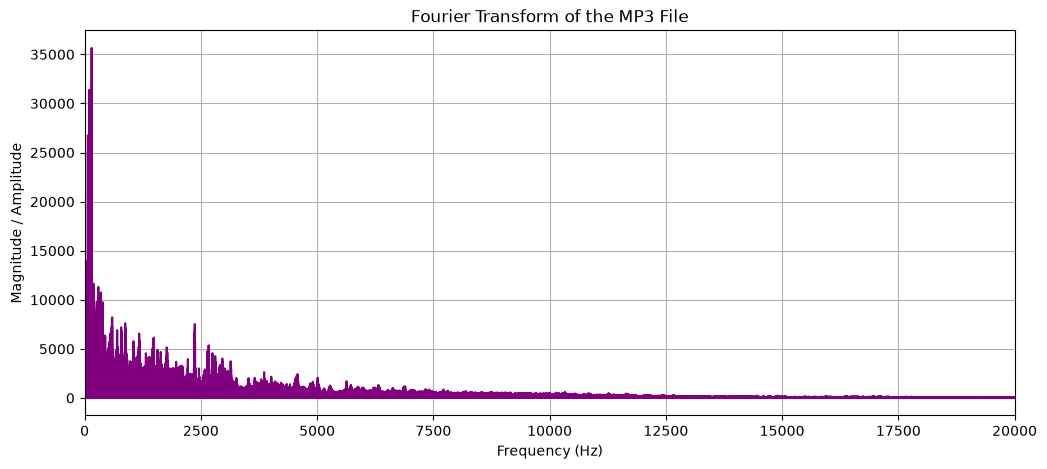

In [13]:
# 4. Plot the results
plt.figure(figsize=(12, 5))
plt.plot(positive_frequencies, magnitude, color='purple')
plt.title("Fourier Transform of the MP3 File")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude / Amplitude")
plt.xlim(0, 20000) # Limit to 20kHz, the edge of human hearing
plt.grid()
plt.show()

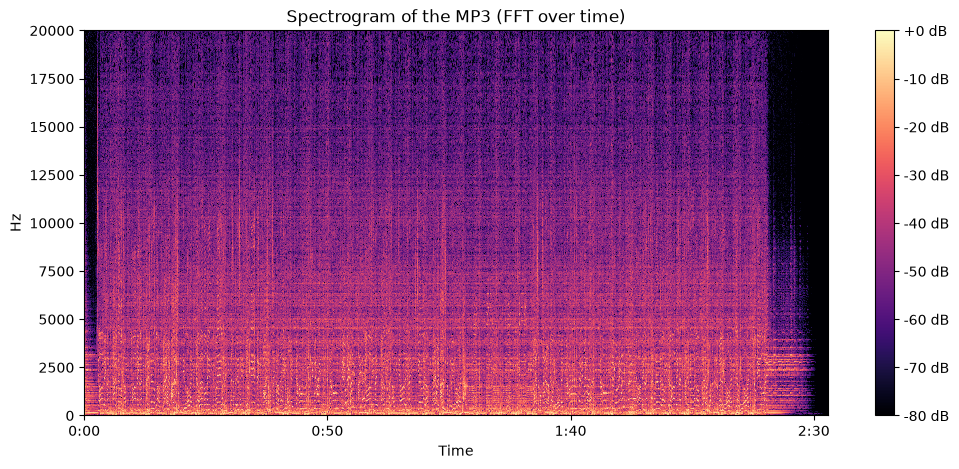

In [14]:
# Compute Short-Time Fourier Transform
stft_matrix = librosa.stft(y)
stft_db = librosa.amplitude_to_db(np.abs(stft_matrix), ref=np.max)

# Plot the Spectrogram (Time vs Frequency vs Intensity)
plt.figure(figsize=(12, 5))
librosa.display.specshow(stft_db, sr=sr, x_axis='time', y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of the MP3 (FFT over time)')
plt.ylim(0, 20000)
plt.show()

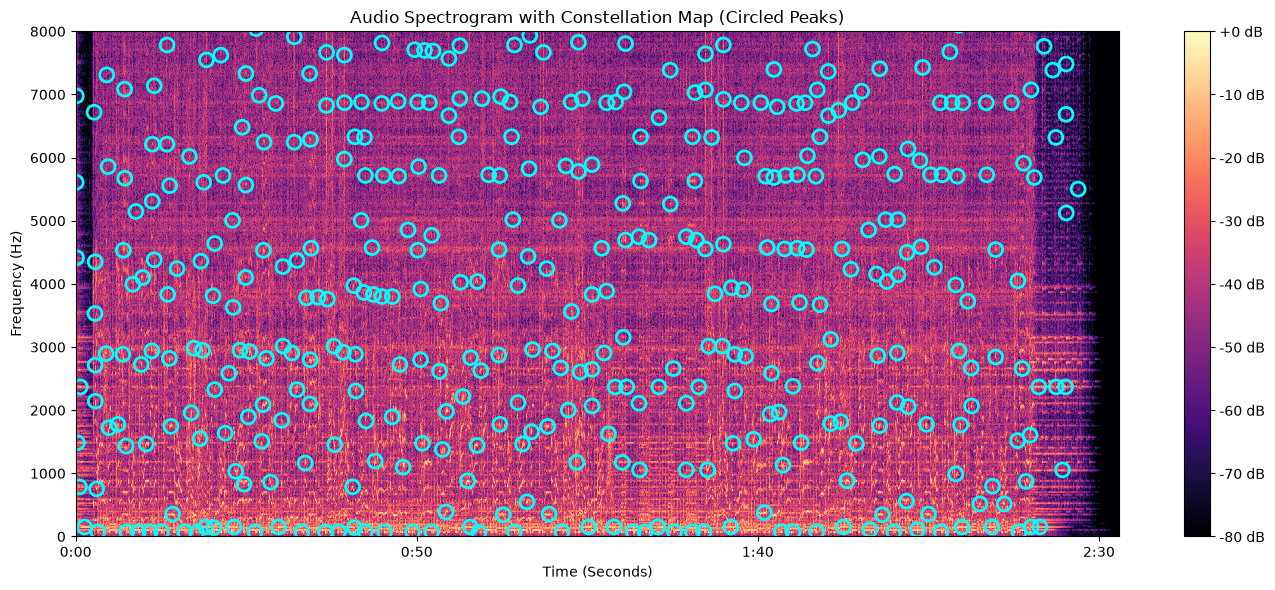

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

# 1. Load a short audio clip (first 5 seconds to keep it clean)
y, sr = librosa.load('./song data/A Hard Day_s Night.mp3')

# 2. Compute the Spectrogram (STFT)
S = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
S_db = librosa.amplitude_to_db(S, ref=np.max)

# 3. Find Local Maxima (The Constellation Peaks)
# We define a neighborhood size (e.g., look 10 frequency bins and 10 time frames around each pixel)
neighborhood_size = (100, 100)
local_max = maximum_filter(S_db, size=neighborhood_size) == S_db

# Filter out background silence: only keep peaks above a certain loudness threshold (e.g., -40 dB)
background_threshold = -40
peaks = local_max & (S_db > background_threshold)

# Get the coordinates of our "stars"
frequency_indices, time_indices = np.where(peaks)

# Convert indices back into actual Time (seconds) and Frequency (Hz) for plotting
frequencies = librosa.fft_frequencies(sr=sr, n_fft=2048)
times = librosa.frames_to_time(np.arange(S_db.shape[1]), sr=sr, hop_length=512)

peak_times = times[time_indices]
peak_freqs = frequencies[frequency_indices]

# 4. Plot the Spectrogram and Circle the Constellation!
plt.figure(figsize=(14, 6))

# Plot the standard spectrogram background
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time', y_axis='linear', cmap='magma')
plt.colorbar(format='%+2.0f dB')

# Superimpose/Circle the constellation peaks on top
plt.scatter(peak_times, peak_freqs, edgecolors='cyan', facecolors='none', s=100, linewidths=2, label='Constellation Peaks')

plt.title("Audio Spectrogram with Constellation Map (Circled Peaks)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (Seconds)")
plt.ylim(0, 8000) 
plt.tight_layout()
plt.show()

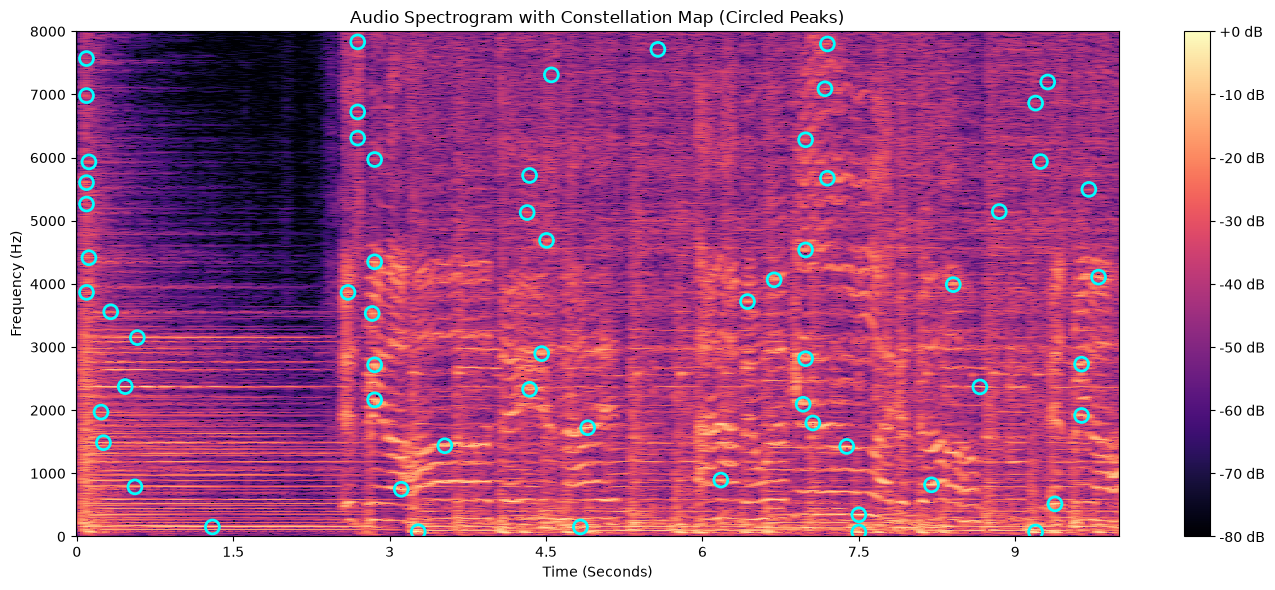

In [6]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

# 1. Load a short audio clip (first 5 seconds to keep it clean)
y, sr = librosa.load('./song data/A Hard Day_s Night.mp3')

# 2. Compute the Spectrogram (STFT)
S = np.abs(librosa.stft(y, n_fft=4096, hop_length=512))
S_db = librosa.amplitude_to_db(S, ref=np.max)

# 3. Find Local Maxima (The Constellation Peaks)
# We define a neighborhood size (e.g., look 10 frequency bins and 10 time frames around each pixel)
neighborhood_size = (100, 100)
local_max = maximum_filter(S_db, size=neighborhood_size) == S_db

# Filter out background silence: only keep peaks above a certain loudness threshold (e.g., -40 dB)
background_threshold = -40
peaks = local_max & (S_db > background_threshold)

# Get the coordinates of our "stars"
frequency_indices, time_indices = np.where(peaks)

# Convert indices back into actual Time (seconds) and Frequency (Hz) for plotting
frequencies = librosa.fft_frequencies(sr=sr, n_fft=4096)
times = librosa.frames_to_time(np.arange(S_db.shape[1]), sr=sr, hop_length=512)

peak_times = times[time_indices]
peak_freqs = frequencies[frequency_indices]

# 4. Plot the Spectrogram and Circle the Constellation!
plt.figure(figsize=(14, 6))

# Plot the standard spectrogram background
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time', y_axis='linear', cmap='magma')
plt.colorbar(format='%+2.0f dB')

# Superimpose/Circle the constellation peaks on top
plt.scatter(peak_times, peak_freqs, edgecolors='cyan', facecolors='none', s=100, linewidths=2, label='Constellation Peaks')

plt.title("Audio Spectrogram with Constellation Map (Circled Peaks)")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (Seconds)")
plt.ylim(0, 8000) 
plt.tight_layout()
plt.show()

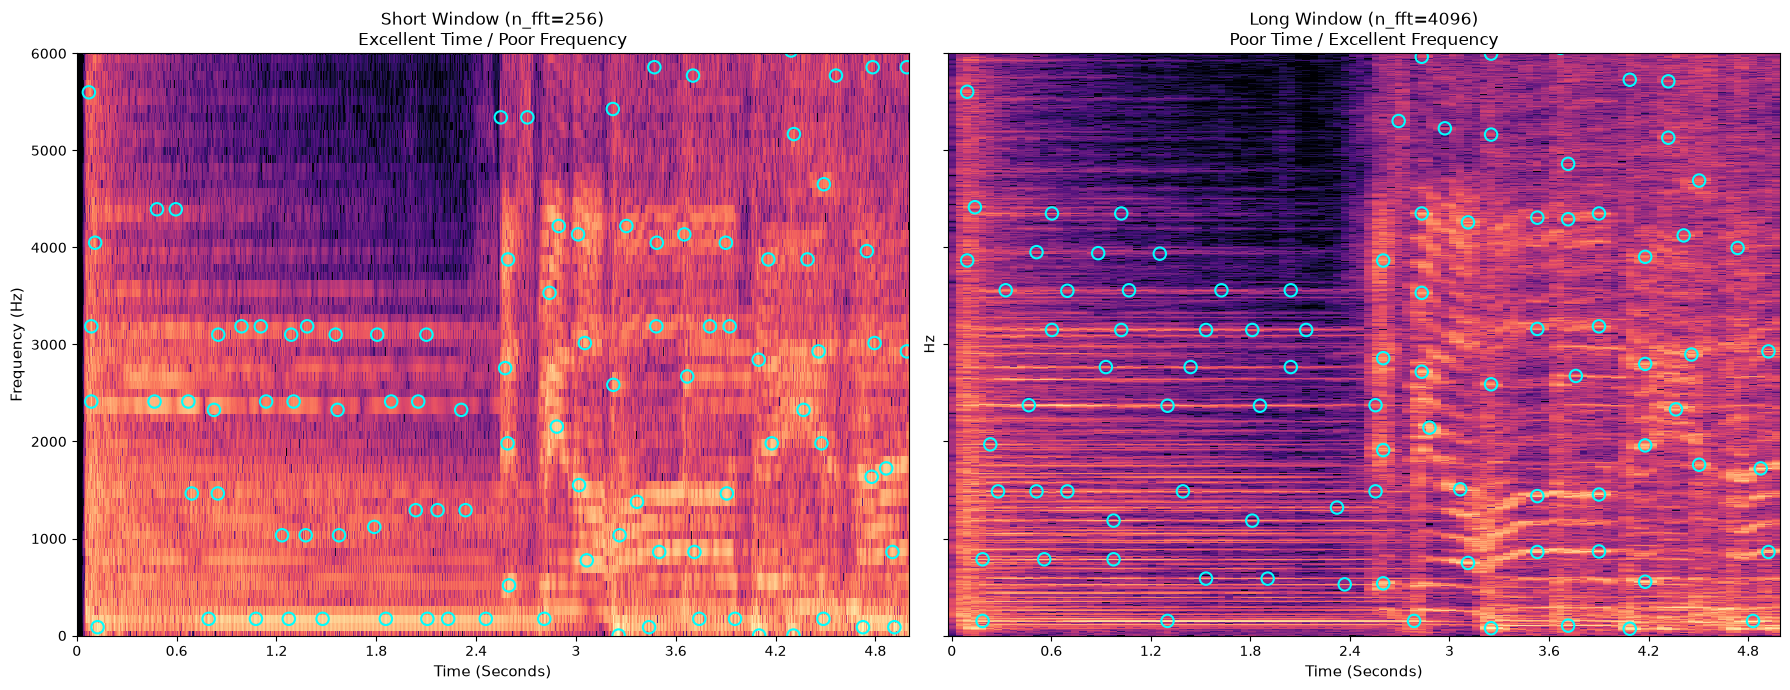

In [2]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

def run_window_experiment(audio_path):
    # Enforce duration=5 to cleanly inspect the visual changes
    y, sr = librosa.load(audio_path, duration=5)
    
    # -----------------------------------------------------------------
    # CONFIGURATION 1: SHORT WINDOW (Focus on Time)
    # -----------------------------------------------------------------
    n_fft_short = 256
    hop_short = 64
    S_short = np.abs(librosa.stft(y, n_fft=n_fft_short, hop_length=hop_short))
    S_db_short = librosa.amplitude_to_db(S_short, ref=np.max)
    
    # Grid size in pixels: looking over a smaller frequency range 
    # but wider time window to match physical scale
    short_neighborhood = (15, 60) 
    local_max_short = maximum_filter(S_db_short, size=short_neighborhood) == S_db_short
    peaks_short = local_max_short & (S_db_short > -40)
    freq_idx_s, time_idx_s = np.where(peaks_short)
    
    freqs_s = librosa.fft_frequencies(sr=sr, n_fft=n_fft_short)
    times_s = librosa.frames_to_time(np.arange(S_db_short.shape[1]), sr=sr, hop_length=hop_short)
    
    # -----------------------------------------------------------------
    # CONFIGURATION 2: LONG WINDOW (Focus on Frequency)
    # -----------------------------------------------------------------
    n_fft_long = 4096
    hop_long = 1024
    S_long = np.abs(librosa.stft(y, n_fft=n_fft_long, hop_length=hop_long))
    S_db_long = librosa.amplitude_to_db(S_long, ref=np.max)
    
    # Grid size in pixels: looking over more frequency bins 
    # but fewer time frames because frames are physically wider
    long_neighborhood = (120, 8) 
    local_max_long = maximum_filter(S_db_long, size=long_neighborhood) == S_db_long
    peaks_long = local_max_long & (S_db_long > -40)
    freq_idx_l, time_idx_l = np.where(peaks_long)
    
    freqs_l = librosa.fft_frequencies(sr=sr, n_fft=n_fft_long)
    times_l = librosa.frames_to_time(np.arange(S_db_long.shape[1]), sr=sr, hop_length=hop_long)

    # -----------------------------------------------------------------
    # PLOTTING AND COMPARISON
    # -----------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
    
    # Plot Short Window
    axes[0].set_title(f"Short Window (n_fft={n_fft_short})\nExcellent Time / Poor Frequency", fontsize=12)
    img1 = librosa.display.specshow(S_db_short, sr=sr, hop_length=hop_short, 
                                    x_axis='time', y_axis='linear', ax=axes[0], cmap='magma')
    axes[0].scatter(times_s[time_idx_s], freqs_s[freq_idx_s], 
                    edgecolors='cyan', facecolors='none', s=80, linewidths=1.5, label='Peaks')
    axes[0].set_ylabel("Frequency (Hz)", fontsize=11)
    axes[0].set_xlabel("Time (Seconds)", fontsize=11)
    axes[0].set_ylim(0, 6000)
    
    # Plot Long Window
    axes[1].set_title(f"Long Window (n_fft={n_fft_long})\nPoor Time / Excellent Frequency", fontsize=12)
    img2 = librosa.display.specshow(S_db_long, sr=sr, hop_length=hop_long, 
                                    x_axis='time', y_axis='linear', ax=axes[1], cmap='magma')
    axes[1].scatter(times_l[time_idx_l], freqs_l[freq_idx_l], 
                    edgecolors='cyan', facecolors='none', s=80, linewidths=1.5, label='Peaks')
    axes[1].set_xlabel("Time (Seconds)", fontsize=11)
    axes[1].set_ylim(0, 6000)
    
    plt.tight_layout()
    plt.show()

# Run the experiment using your file path
run_window_experiment('./song data/A Hard Day_s Night.mp3')

In [ ]:
import os
import librosa
import numpy as np
import scipy.ndimage as ndimage

# =====================================================================
# CONFIGURATION & HYPERPARAMETERS
# =====================================================================
SONGS_DIR = "./song data"               # Folder containing your complete database tracks (.mp3/.wav)
QUERY_SNIPPET = "./query_snippet.mp3"    # The short, noisy clip you want to identify

# Signal Processing Parameters
SAMPLING_RATE = None                    # None preserves the audio's native sampling rate
FFT_WINDOW_SIZE = 2048                  # Balanced window size (n_fft) for time/frequency resolution
HOP_LENGTH = 512                        # Step size between successive frames

# Peak Detection & Sparsification Parameters
NEIGHBORHOOD_SIZE = (20, 20)            # Size of the 2D footprint to clear out non-maximal peaks
BACKGROUND_THRESHOLD = -40              # Loudness threshold in dB to filter out background noise/silence

# =====================================================================
# CORE FINGERPRINTING FUNCTIONS
# =====================================================================

def extract_constellation_map(audio_path, duration=None):
    """
    Loads an audio track, computes its STFT spectrogram, applies 2D local
    maxima filtering and loudness thresholding to extract a sparse set 
    of standout spectral peaks (the constellation map).
    """
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"Audio file not found at: {audio_path}")

    # 1. Load audio signal
    y, sr = librosa.load(audio_path, sr=SAMPLING_RATE, duration=duration)
    
    # 2. Compute Short-Time Fourier Transform (STFT) magnitude
    stft_matrix = librosa.stft(y, n_fft=FFT_WINDOW_SIZE, hop_length=HOP_LENGTH)
    spectrogram = np.abs(stft_matrix)
    
    # 3. Convert magnitude to decibels relative to peak intensity
    spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)
    
    # 4. Perform local maxima search using a 2D maximum filter footprint
    local_max_mask = ndimage.maximum_filter(spectrogram_db, size=NEIGHBORHOOD_SIZE) == spectrogram_db
    
    # 5. Enforce loudness thresholding to reject low-amplitude noise
    threshold_mask = spectrogram_db > BACKGROUND_THRESHOLD
    
    # 6. Combine masks to extract final high-intensity peak coordinates
    peaks_mask = local_max_mask & threshold_mask
    freq_indices, time_indices = np.where(peaks_mask)
    
    # Return as a set of coordinates: (frequency_bin, time_frame)
    return list(zip(freq_indices, time_indices))


# =====================================================================
# DATABASE MANAGEMENT (INDEXING PHASE)
# =====================================================================

def build_song_database(folder_path):
    """
    Scans the source folder for audio files, extracts full fingerprints, 
    and catalogs them into an in-memory structural dictionary.
    """
    database = {}
    if not os.path.exists(folder_path):
        print(f"Creating directory '{folder_path}'... Please add your full audio tracks there.")
        os.makedirs(folder_path)
        return database

    valid_extensions = ('.mp3', '.wav', '.m4a', '.flac')
    audio_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]

    if not audio_files:
        print(f"No audio files found in '{folder_path}'. Populate it with songs to search against.")
        return database

    print(f"--- Starting Database Indexing ({len(audio_files)} files found) ---")
    for file_name in audio_files:
        full_path = os.path.join(folder_path, file_name)
        print(f"Indexing track: '{file_name}'...")
        try:
            # Extract peaks across the entire duration of the reference song
            peaks = extract_constellation_map(full_path, duration=None)
            database[file_name] = peaks
        except Exception as e:
            print(f"Failed to index {file_name}: {e}")
            
    print("--- Database Indexing Complete ---\n")
    return database


# =====================================================================
# MATCHING ENGINE (QUERY PHASE)
# =====================================================================

def match_snippet(query_path, database, query_duration=5):
    """
    Extracts fingerprints from a short snippet and aligns it across time 
    with all indexed songs in the database using relative offset histograms.
    """
    if not database:
        print("Matching aborted: Database is empty.")
        return None

    print(f"--- Processing Query Snippet: {query_path} ---")
    try:
        query_peaks = extract_constellation_map(query_path, duration=query_duration)
    except Exception as e:
        print(f"Error processing query file: {e}")
        return None

    best_track_match = None
    highest_coincidence_score = 0

    print("Evaluating coincidence alignments across database entries:")
    
    for song_name, db_peaks in database.items():
        # Map DB frequencies to time frames for highly efficient O(1) matching checks
        db_freq_map = {}
        for db_f, db_t in db_peaks:
            db_freq_map.setdefault(db_f, []).append(db_t)

        # Dictionary to track occurrence frequencies of time offsets: (t_db - t_query)
        offset_histogram = {}

        # Scan through snippet peaks and look for common frequency coordinates
        for q_f, q_t in query_peaks:
            if q_f in db_freq_map:
                for db_t in db_freq_map[q_f]:
                    # Calculate structural time distance
                    time_offset = db_t - q_t
                    offset_histogram[time_offset] = offset_histogram.get(time_offset, 0) + 1

        # The peak count at the single most highly aligned offset represents the true score
        if offset_histogram:
            max_alignment_score = max(offset_histogram.values())
            print(f" -> Track: {song_name:.<40} Max Alignment Score: {max_alignment_score}")
            
            if max_alignment_score > highest_coincidence_score:
                highest_coincidence_score = max_alignment_score
                best_track_match = song_name
        else:
            print(f" -> Track: {song_name:.<40} Max Alignment Score: 0")

    print("\n=====================================================================")
    if best_track_match and highest_coincidence_score > 0:
        print(f" MATCH IDENTIFIED: '{best_track_match}'")
        print(f" Confidence Alignment Score: {highest_coincidence_score} intersecting peaks")
    else:
        print(" MATCHING FAILED: No significant structural overlap discovered.")
    print("=====================================================================")
    
    return best_track_match


# =====================================================================
# EXECUTION ENTRY POINT
# =====================================================================
if __name__ == "__main__":
    # 1. Initialize and build local fingerprint catalog from your multi-song directory
    song_db = build_song_database(SONGS_DIR)
    
    # 2. Run matching analysis if an input query clip is available
    if os.path.exists(QUERY_SNIPPET):
        match_snippet(QUERY_SNIPPET, song_db, query_duration=5)
    else:
        print(f"\nTo test queries, place a short snippet sample at '{QUERY_SNIPPET}'")

In [3]:
import os
import librosa
import numpy as np
import scipy.ndimage as ndimage
from collections import defaultdict

# =====================================================================
# CONFIGURATION & HYPERPARAMETERS
# =====================================================================
SONGS_DIR = "./song data"               
QUERY_SNIPPET = "./song data/Can_t Buy Me Love.mp3"    

# Signal Processing Parameters
SAMPLING_RATE = None                    
FFT_WINDOW_SIZE = 2048                  
HOP_LENGTH = 512                        

# Peak Detection & Sparsification Parameters
NEIGHBORHOOD_SIZE = (20, 20)            
BACKGROUND_THRESHOLD = -40              
FAN_VALUE = 5                           # Number of target peaks to pair with each anchor peak

# =====================================================================
# CORE FINGERPRINTING & HASHING FUNCTIONS
# =====================================================================

def extract_constellation_map(audio_path, duration=None):
    """
    Extracts a sparse set of standout spectral peaks from the audio.
    """
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"Audio file not found at: {audio_path}")

    y, sr = librosa.load(audio_path, sr=SAMPLING_RATE, duration=duration)
    
    stft_matrix = librosa.stft(y, n_fft=FFT_WINDOW_SIZE, hop_length=HOP_LENGTH)
    spectrogram_db = librosa.amplitude_to_db(np.abs(stft_matrix), ref=np.max)
    
    local_max_mask = ndimage.maximum_filter(spectrogram_db, size=NEIGHBORHOOD_SIZE) == spectrogram_db
    threshold_mask = spectrogram_db > BACKGROUND_THRESHOLD
    
    peaks_mask = local_max_mask & threshold_mask
    freq_indices, time_indices = np.where(peaks_mask)
    
    # Return mapped coordinates: (frequency_bin, time_frame)
    return list(zip(freq_indices, time_indices))

def generate_hashes(peaks, fan_value=FAN_VALUE):
    """
    Converts a list of (freq, time) peaks into structurally rare hashes.
    Hash format: (f1, f2, delta_t) -> anchor_time
    """
    hashes = []
    
    # Sort peaks chronologically to only pair with future events
    peaks = sorted(peaks, key=lambda x: x[1])
    num_peaks = len(peaks)
    
    for i in range(num_peaks):
        anchor_freq, anchor_time = peaks[i]
        
        # Pair with the next 'fan_value' peaks
        for j in range(1, fan_value + 1):
            if i + j < num_peaks:
                target_freq, target_time = peaks[i + j]
                
                # delta_t is the rhythmic time gap between the two specific frequencies
                time_delta = target_time - anchor_time
                
                # The hash tuple: (f1, f2, delta_t)
                hash_tuple = (int(anchor_freq), int(target_freq), int(time_delta))
                
                # Append the hash along with the absolute time it occurred
                hashes.append({
                    'hash': hash_tuple,
                    'absolute_time': anchor_time
                })
                
    return hashes

# =====================================================================
# DATABASE MANAGEMENT (INDEXING PHASE)
# =====================================================================

def build_song_database(folder_path):
    """
    Scans the folder, extracts hashes for every song, and catalogs them 
    into a massive hash-table mapping: Hash -> List of (Song_Name, Absolute_Time)
    """
    # Using defaultdict to easily append multiple occurrences of the same hash
    database = defaultdict(list)
    
    if not os.path.exists(folder_path):
        print(f"Creating directory '{folder_path}'... Please add your full audio tracks there.")
        os.makedirs(folder_path)
        return database

    valid_extensions = ('.mp3', '.wav', '.m4a', '.flac')
    audio_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]

    if not audio_files:
        print(f"No audio files found in '{folder_path}'. Populate it with songs.")
        return database

    print(f"--- Starting Database Indexing ({len(audio_files)} files found) ---")
    for file_name in audio_files:
        full_path = os.path.join(folder_path, file_name)
        print(f"Indexing track: '{file_name}'...")
        
        # 1. Extract peaks
        peaks = extract_constellation_map(full_path, duration=None)
        # 2. Generate complex pairs (hashes)
        song_hashes = generate_hashes(peaks)
        
        # 3. Store in the global database
        for h in song_hashes:
            database[h['hash']].append((file_name, h['absolute_time']))
            
    print("--- Database Indexing Complete ---\n")
    return database

# =====================================================================
# MATCHING ENGINE (QUERY PHASE)
# =====================================================================

def match_snippet(query_path, database, query_duration=5):
    """
    Extracts hashes from a short snippet and finds the track with the 
    most consistently aligned time-offsets.
    """
    if not database:
        print("Matching aborted: Database is empty.")
        return None

    print(f"--- Processing Query Snippet: {query_path} ---")
    
    # 1. Fingerprint the query
    query_peaks = extract_constellation_map(query_path, duration=query_duration)
    query_hashes = generate_hashes(query_peaks)

    # Dictionary to track occurrence of specific time offsets per song: (Song_Name, Offset) -> Count
    offset_tallies = defaultdict(int)
    
    print("Evaluating hash collisions and structural alignments...")
    
    # 2. Look up every query hash in our database
    for q_hash in query_hashes:
        hash_val = q_hash['hash']
        q_time = q_hash['absolute_time']
        
        # If this highly specific hash exists in our database...
        if hash_val in database:
            # Check every time this hash occurred across all indexed songs
            matches = database[hash_val]
            for song_name, db_time in matches:
                
                # Calculate the structural time offset
                time_offset = db_time - q_time
                
                # Tally this alignment
                offset_tallies[(song_name, time_offset)] += 1

    # 3. Find the definitive spike in the histogram
    if not offset_tallies:
        print(" MATCHING FAILED: Zero structural hash overlaps discovered.")
        return None
        
    best_match = max(offset_tallies, key=offset_tallies.get)
    best_song, best_offset = best_match
    highest_score = offset_tallies[best_match]
    
    print("\n=====================================================================")
    if highest_score > 5: # Small arbitrary threshold to ensure it wasn't random noise
        print(f" MATCH IDENTIFIED: '{best_song}'")
        print(f" Alignment Offset: {best_offset} frames")
        print(f" Confidence Score: {highest_score} perfectly aligned structural hashes")
    else:
        print(" MATCHING FAILED: Insufficient structural overlap discovered.")
    print("=====================================================================")
    
    return best_song

# =====================================================================
# EXECUTION ENTRY POINT
# =====================================================================
if __name__ == "__main__":
    # 1. Build database from directory
    song_db = build_song_database(SONGS_DIR)
    
    # 2. Test the query
    if os.path.exists(QUERY_SNIPPET):
        match_snippet(QUERY_SNIPPET, song_db, query_duration=5)
    else:
        print(f"\nTo test queries, place a short snippet sample at '{QUERY_SNIPPET}'")

--- Starting Database Indexing (50 files found) ---
Indexing track: 'A Day In The Life.mp3'...
Indexing track: 'A Hard Day_s Night.mp3'...
Indexing track: 'Across The Universe.mp3'...
Indexing track: 'Back In The U.S.S.R..mp3'...
Indexing track: 'Blackbird.mp3'...
Indexing track: 'Bohemian Rhapsody.mp3'...
Indexing track: 'Can_t Buy Me Love.mp3'...
Indexing track: 'Crazy Little Thing Called Love.mp3'...
Indexing track: 'Day Tripper.mp3'...
Indexing track: 'Don_t Stop Me Now.mp3'...
Indexing track: 'Drive My Car.mp3'...
Indexing track: 'Eight Days A Week.mp3'...
Indexing track: 'Eleanor Rigby.mp3'...
Indexing track: 'Get Back.mp3'...
Indexing track: 'Hello, Goodbye.mp3'...
Indexing track: 'Help!.mp3'...
Indexing track: 'Helter Skelter.mp3'...
Indexing track: 'Hey Jude.mp3'...
Indexing track: 'I Am The Walrus.mp3'...
Indexing track: 'I Saw Her Standing There.mp3'...
Indexing track: 'I Want It All.mp3'...
Indexing track: 'I Want To Hold Your Hand.mp3'...
Indexing track: 'In My Life.mp3'..

In [14]:
import os
import csv
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# (Assume extract_constellation_map, generate_hashes, and the database are available from previous steps)

# =====================================================================
# MODE I: SINGLE-CLIP DIAGNOSTIC MODE
# =====================================================================

def single_clip_mode(query_path, database, query_duration=5):
    """
    Identifies a single query clip and visualizes the intermediate processing steps:
    1. The Spectrogram
    2. The Constellation of Peaks
    3. The Offset Histogram
    """
    print(f"\n--- Running Single-Clip Mode: {query_path} ---")
    
    # 1. Extract peaks and generate hashes
    y, sr = librosa.load(query_path, sr=None, duration=query_duration)
    stft_matrix = librosa.stft(y, n_fft=2048, hop_length=512)
    spectrogram_db = librosa.amplitude_to_db(np.abs(stft_matrix), ref=np.max)
    
    query_peaks = extract_constellation_map(query_path, duration=query_duration)
    query_hashes = generate_hashes(query_peaks)

    # 2. Match against database
    offset_tallies = defaultdict(int)
    song_histograms = defaultdict(lambda: defaultdict(int))
    
    for q_hash in query_hashes:
        hash_val = q_hash['hash']
        q_time = q_hash['absolute_time']
        
        if hash_val in database:
            for song_name, db_time in database[hash_val]:
                time_offset = db_time - q_time
                offset_tallies[(song_name, time_offset)] += 1
                song_histograms[song_name][time_offset] += 1

    if not offset_tallies:
        print("No matches found.")
        return

    # 3. Determine the best match
    best_match = max(offset_tallies, key=offset_tallies.get)
    best_song, best_offset = best_match

    #Verification
    print(best_match)
    print(offset_tallies[best_match])

    print(song_histograms[best_song][best_offset])
    #verification
    
    print(f"Prediction: {best_song} (Offset Spike: {offset_tallies[best_match]} matches)")

    # 4. Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot A: Spectrogram
    librosa.display.specshow(spectrogram_db, sr=sr, hop_length=512, x_axis='time', y_axis='linear', ax=axes[0], cmap='magma')
    axes[0].set_title("1. Spectrogram")
    axes[0].set_ylim(0, 8000)
    
    # Plot B: Constellation Map
    librosa.display.specshow(spectrogram_db, sr=sr, hop_length=512, x_axis='time', y_axis='linear', ax=axes[1], cmap='magma')
    freq_bins, time_frames = zip(*query_peaks)
    
    # Convert bins/frames back to Hz/Seconds for accurate plotting overlay
    times = librosa.frames_to_time(time_frames, sr=sr, hop_length=512)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=2048)[list(freq_bins)]
    
    axes[1].scatter(times, freqs, edgecolor='cyan', facecolor='none', s=50, label='Peaks')
    axes[1].set_title("2. Constellation of Peaks")
    axes[1].set_ylim(0, 8000)

    # Plot C: Offset Histogram for the Best Matched Song
    best_song_data = song_histograms[best_song]

    sorted_items = sorted(best_song_data.items())

    offsets = [k for k, v in sorted_items]
    counts  = [v for k, v in sorted_items]

    axes[2].plot(offsets, counts)
    axes[2].set_title(f"3. Offset Histogram ({best_song})")
    axes[2].set_xlabel("Time Offset (Frames)")
    axes[2].set_ylabel("Number of Hash Matches")
    
    plt.tight_layout()
    plt.show()

# =====================================================================
# MODE II: BATCH EVALUATION MODE
# =====================================================================

def batch_mode(queries_dir, database, output_csv="results.csv"):
    """
    Processes a directory of query clips and writes the predictions 
    to a strictly formatted CSV file.
    """
    print(f"\n--- Running Batch Mode on directory: {queries_dir} ---")
    
    if not os.path.exists(queries_dir):
        print(f"Error: Directory '{queries_dir}' not found.")
        return

    query_files = [f for f in os.listdir(queries_dir) if f.lower().endswith(('.mp3', '.wav'))]
    results = []

    for file_name in query_files:
        full_path = os.path.join(queries_dir, file_name)
        
        # 1. Fingerprint the query
        try:
            query_peaks = extract_constellation_map(full_path, duration=5)
            query_hashes = generate_hashes(query_peaks)
        except Exception as e:
            print(f"Failed to process {file_name}: {e}")
            results.append([file_name, "ERROR"])
            continue

        # 2. Match against database
        offset_tallies = defaultdict(int)
        for q_hash in query_hashes:
            hash_val = q_hash['hash']
            if hash_val in database:
                for song_name, db_time in database[hash_val]:
                    time_offset = db_time - q_hash['absolute_time']
                    offset_tallies[(song_name, time_offset)] += 1

        # 3. Predict the song
        if offset_tallies:
            best_match = max(offset_tallies, key=offset_tallies.get)
            best_song_filename = best_match[0]
            
            # Format prediction: remove the extension from the matched song's filename
            prediction = os.path.splitext(best_song_filename)[0]
        else:
            prediction = "NO_MATCH"
            
        results.append([file_name, prediction])

    # 4. Write exactly to CSV format requested
    with open(output_csv, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(["filename", "prediction"])
        writer.writerows(results)
        
    print(f"Batch processing complete. Results saved to '{output_csv}'.")


--- Running Single-Clip Mode: ./song data/Help!.mp3 ---
('Help!.mp3', np.int64(0))
2151
2151
Prediction: Help!.mp3 (Offset Spike: 2151 matches)


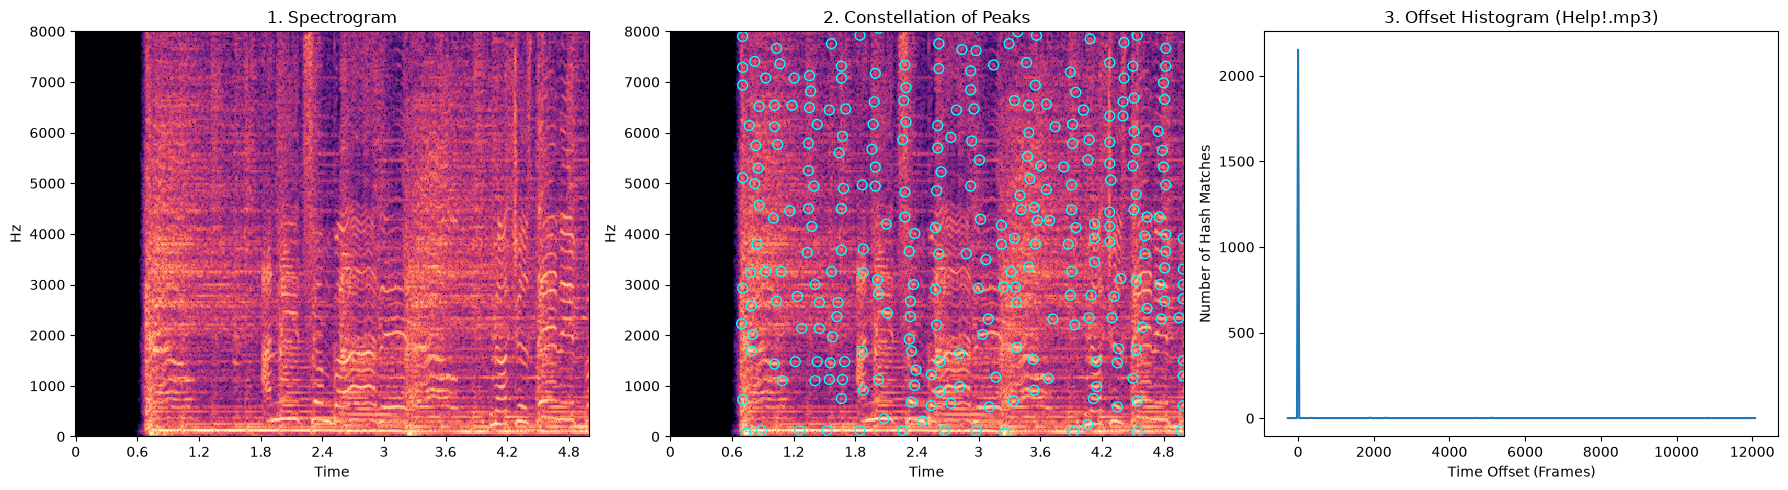

In [15]:
single_clip_mode("./song data/Help!.mp3", song_db, query_duration=5)

In [16]:
batch_mode('./trial', song_db)


--- Running Batch Mode on directory: ./trial ---
Batch processing complete. Results saved to 'results.csv'.


In [17]:
%pip install streamlit

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.2 MB 8.5 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.2 MB 10.1 MB/s eta 0:00:01
   ------------------------- -------------- 5.8/9.2 MB 10.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.2 MB 9.9 MB/s eta 0:00:01
   ------------------------------------- -- 8.7/9.2 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------- 9.2/9.2 MB 8.4 MB/s  0:00:01
   ---------------------------------------- 0.0/797.5 kB ? eta -:--:--
   ---------------------------------------- 797.5/797.5 kB 5.7 MB/s  0:00:00
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.3 MB 8.4 MB/s eta 0:00:02
   ----- ---------------------------------- 1.6/11.3 MB 3.6 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/11.3 MB 5.3 MB/s eta 0:00:02
   ------------------ -----

In [18]:
%pip install librosa scipy matplotlib pandas soundfile tqdm

Note: you may need to restart the kernel to use updated packages.
